In [29]:
# ==========================================
# Cell 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("All libraries imported successfully!")

All libraries imported successfully!


In [30]:
# ==========================================
# Cell 2: Load the Dataset
# ==========================================

# Read the dataset
df = pd.read_csv(
    "data/household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values="?",
    nrows=50000
)





print(df.head())

print("\nDataset Shape:")
print(df.shape)

         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  

Dataset Shape:
(50000, 9)


In [31]:
# ==========================================
# Cell 3: Explore the Dataset
# ==========================================

print("Dataset Information:\n")
df.info()

print("\n\nMissing Values:\n")
print(df.isnull().sum())

print("\n\nStatistical Summary:\n")
print(df.describe())

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   50000 non-null  str    
 1   Time                   50000 non-null  str    
 2   Global_active_power    49995 non-null  float64
 3   Global_reactive_power  49995 non-null  float64
 4   Voltage                49995 non-null  float64
 5   Global_intensity       49995 non-null  float64
 6   Sub_metering_1         49995 non-null  float64
 7   Sub_metering_2         49995 non-null  float64
 8   Sub_metering_3         49995 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.4 MB


Missing Values:

Date                     0
Time                     0
Global_active_power      5
Global_reactive_power    5
Voltage                  5
Global_intensity         5
Sub_metering_1           5
Sub_metering_2           5
Sub_metering_3           5

In [32]:
# ==========================================
# Cell 4: Data Cleaning and DateTime Conversion
# ==========================================

# Combine Date and Time into a single Datetime column
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

# Convert all numerical columns to numeric datatype
columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing values
df = df.dropna()

# Keep only the required columns
df = df[["Datetime", "Global_active_power"]]

# Display the cleaned dataset
print("Cleaned Dataset:")
print(df.head())

print("\nDataset Shape After Cleaning:")
print(df.shape)

Cleaned Dataset:
             Datetime  Global_active_power
0 2006-12-16 17:24:00                4.216
1 2006-12-16 17:25:00                5.360
2 2006-12-16 17:26:00                5.374
3 2006-12-16 17:27:00                5.388
4 2006-12-16 17:28:00                3.666

Dataset Shape After Cleaning:
(49995, 2)


In [33]:
# ==========================================
# Cell 5: Feature Scaling
# ==========================================

# Create a MinMaxScaler object
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale the Global Active Power column
scaled_data = scaler.fit_transform(df[["Global_active_power"]])

print("Scaled Data Shape:", scaled_data.shape)

print("\nFirst 10 Scaled Values:")
print(scaled_data[:10])

Scaled Data Shape: (49995, 1)

First 10 Scaled Values:
[[0.44304913]
 [0.56906808]
 [0.57061027]
 [0.57215246]
 [0.3824631 ]
 [0.36638026]
 [0.38642873]
 [0.38620842]
 [0.38268341]
 [0.38202247]]


In [34]:
# ==========================================
# Cell 6: Create Sequences
# ==========================================

import numpy as np

X = []
y = []

sequence_length = 24   # use previous 24 readings to predict next one

for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i:i+sequence_length])
    y.append(scaled_data[i+sequence_length])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49971, 24, 1)
y shape: (49971, 1)


In [35]:
# ==========================================
# Cell 7: Split Data into Training and Testing Sets
# ==========================================

# Use 80% of the data for training and 20% for testing
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Data Shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data Shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training Data Shape:
X_train: (39976, 24, 1)
y_train: (39976, 1)

Testing Data Shape:
X_test: (9995, 24, 1)
y_test: (9995, 1)


In [36]:
# ==========================================
# Cell 8: Build LSTM Model
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# LSTM layer
model.add(
    LSTM(
        64,
        input_shape=(24, 1)
    )
)

# Prevent overfitting
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))


model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

c:\Users\krish dubey\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# ==========================================
# Cell 9: Model Training
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0039 - val_loss: 0.0035
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0025 - val_loss: 0.0033
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0021 - val_loss: 0.0025
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0020 - val_loss: 0.0024
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0020 - val_loss: 0.0024
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0020 - val_loss: 0.0025
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0020 - val_loss: 0.0024


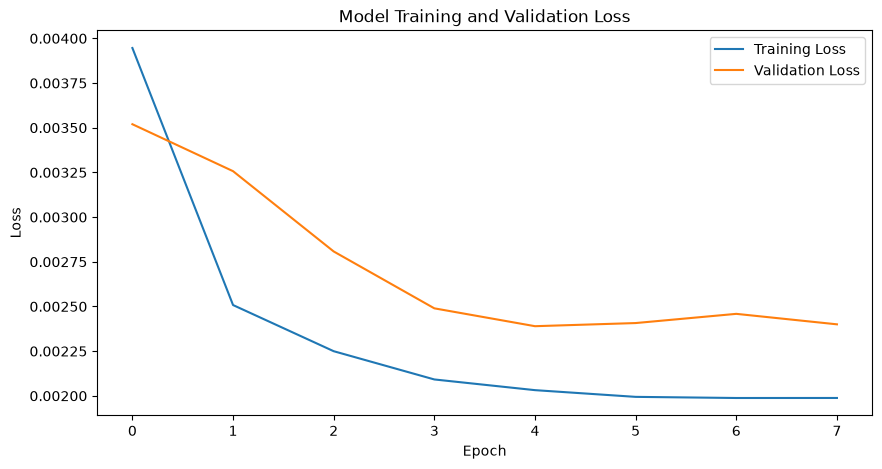

In [40]:
# ==========================================
# Cell 10: Training History Visualization
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Training and Validation Loss")

plt.legend()
plt.show()

In [41]:
# ==========================================
# Cell 11: Prediction
# ==========================================

predictions = model.predict(X_test)

print(predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
(9995, 1)


In [42]:
# ==========================================
# Cell 12: Inverse Scaling
# ==========================================

predicted_power = scaler.inverse_transform(predictions)

actual_power = scaler.inverse_transform(y_test)

print("Predicted:", predicted_power[:5])
print("Actual:", actual_power[:5])

Predicted: [[1.069987 ]
 [1.0299759]
 [1.0195112]
 [1.0610954]
 [1.183166 ]]
Actual: [[0.958]
 [0.972]
 [1.046]
 [1.218]
 [1.204]]


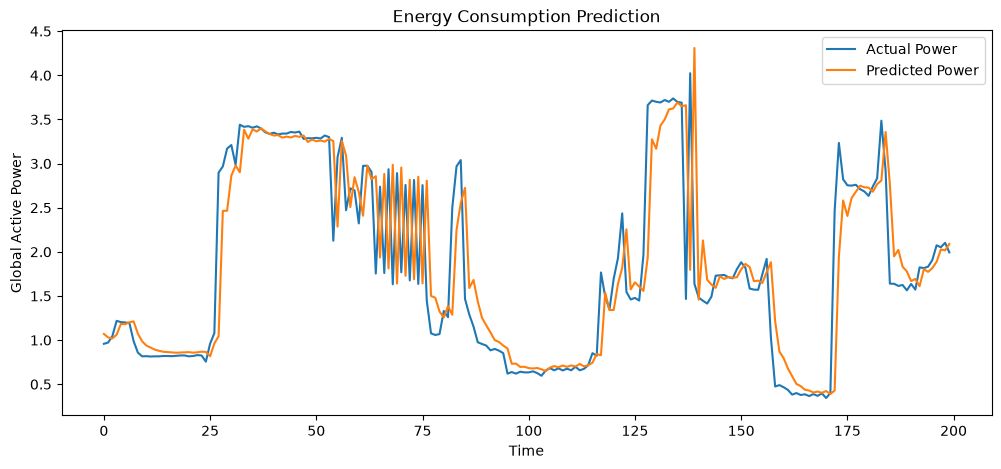

In [43]:
# ==========================================
# Cell 13: Prediction Visualization
# ==========================================

plt.figure(figsize=(12,5))

plt.plot(actual_power[:200], label="Actual Power")
plt.plot(predicted_power[:200], label="Predicted Power")

plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.title("Energy Consumption Prediction")

plt.legend()
plt.show()

In [45]:
# ==========================================
# Cell 14: Evaluate Model
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors
mae = mean_absolute_error(actual_power, predicted_power)

rmse = np.sqrt(
    mean_squared_error(actual_power, predicted_power)
)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.22047753645579415
Root Mean Squared Error (RMSE): 0.44376600242465686


In [ ]:
# ==========================================
# Cell 15: Save Model
# ==========================================

model.save("energy_lstm_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [48]:
# ==========================================
# Cell 16: Future Energy Prediction
# ==========================================

import numpy as np

# Take last 24 values from scaled dataset
last_24 = scaled_data[-24:]

# Reshape for LSTM input
input_data = last_24.reshape(1, 24, 1)

# Predict next value
next_prediction = model.predict(input_data)

# Convert back to original scale
next_power = scaler.inverse_transform(next_prediction)

print("Predicted next energy consumption:")
print(next_power[0][0], "kW")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted next energy consumption:
2.1928153 kW


In [50]:
# ==========================================
# Model Evaluation Metrics
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics

mae = mean_absolute_error(actual_power, predicted_power)

mse = mean_squared_error(actual_power, predicted_power)

rmse = np.sqrt(mse)

r2 = r2_score(actual_power, predicted_power)


print("Model Performance:")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

Model Performance:
-------------------------
MAE  : 0.22047753645579415
MSE  : 0.19692826490796056
RMSE : 0.44376600242465686
R2 Score : 0.8892016455695446
